<div style="display: flex; align-items: center;">
    <div style="display: flex; flex-direction: column; align-items: center;">
        <h1 style="text-align: right;">Centro de Investigación en Matemáticas, A.C.</h1>
        <h2 style="text-align: right;">Modelos Generativos Profundos</h2>
        <h2 style="text-align: right;">Jose Miguel Saavedra Aguilar</h2>
        <h3 style="text-align: right;">Proyecto 1</h3>
    </div>
    <img src="Figures/logoCIMAT11.png" alt="CIMAT Logo" width="200" style="float: left;">
</div>


---

We present the code to replicate the models and experiments discussed in the project. The code is organized into the same sections as the report for clarity.

In [ ]:
# ----------------------------
# Install dependencies
# ----------------------------
!pip install onnx

In [1]:
# ----------------------------
# Import required libraries
# ----------------------------
# Import essential libraries for data processing, visualization, and model building
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import warnings
import os
from tqdm import tqdm

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [2]:
# ----------------------------
# Device selection (GPU/TPU/CPU)
# ----------------------------
# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
# Check for TPU availability (using PyTorch/XLA)
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    # Default to CPU if no GPU or TPU is available
    device = torch.device("cpu")

# Print the selected device
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ----------------------------
# Load data
# ----------------------------
# Load the dataset from a CSV file
df = pd.read_csv("data.csv", header=0, index_col=0)

# Extract labels (y) and features (X)
y_full = df.iloc[:, 0].values.astype(np.int64)     # Labels: 0 or 1
X_full = df.iloc[:, 1:].values.astype(np.float32)  # Features: (N, 1033)

# Print dataset statistics
print(f"Loaded {X_full.shape[0]} users, time-series length = {X_full.shape[1]}")
print(f"Theft ratio: {y_full.mean():.3f} ({(y_full == 1).sum()} theft / {(y_full == 0).sum()} normal)")

Loaded 42372 users, time-series length = 1034
Theft ratio: 0.085 (3615 theft / 38757 normal)


In [4]:
# ----------------------------
# Preprocessing utilities
# ----------------------------
def interpolate_missing(data):
    """Perform linear interpolation for missing values (NaN)."""
    df = pd.DataFrame(data)
    df = df.replace(0, np.nan)  # Replace zeros with NaN (zeros indicate missing values)
    df = df.interpolate(method='linear', limit_direction='both')  # Interpolate missing values
    return df.values

def normalize_data(data):
    """Normalize data using Min-Max scaling."""
    scaler = MinMaxScaler()
    return scaler.fit_transform(data.T).T, scaler  # Normalize each user series independently

In [5]:
# ----------------------------
# Interpolation (paper method)
# ----------------------------
def interpolate_missing_paper(X):
    """
    Vectorized implementation of Eq. (18) from the paper.
    X: (N, L) array of time-series data
    Returns: interpolated X, same shape.
    """
    X = X.copy()
    # Treat 0 and NaN as missing values
    missing = (X == 0) | np.isnan(X)

    # Create shifted views (pad with invalid values at edges)
    left = np.roll(X, 1, axis=1)  # Shift left
    right = np.roll(X, -1, axis=1)  # Shift right

    # Mark edges as invalid (no two neighbors)
    left[:, 0] = 0  # First column has no left neighbor
    right[:, -1] = 0  # Last column has no right neighbor

    # Check if neighbors are valid (not missing and not zero)
    left_valid = ~((left == 0) | np.isnan(left))
    right_valid = ~((right == 0) | np.isnan(right))

    # Apply Eq. (18): only fill if both neighbors are valid
    fill_mask = missing & left_valid & right_valid
    X[fill_mask] = (left[fill_mask] + right[fill_mask]) / 2.0

    # Set all remaining missing values to 0
    X[missing & ~fill_mask] = 0.0

    return X

In [6]:
# ----------------------------
# Preprocessing pipeline: interpolation and scaling
# ----------------------------
def interpolate_missing(data):
    """Perform linear interpolation for missing values (NaN)."""
    df = pd.DataFrame(data)
    df = df.replace(0, np.nan)  # Replace zeros with NaN (zeros indicate missing values)
    df = df.interpolate(method='linear', limit_direction='both')  # Interpolate missing values
    return df.values

# Apply interpolation to the dataset
X_clean = interpolate_missing(X_full)
# X_clean = interpolate_missing_paper(X)  # Uncomment to use the paper's interpolation method

# Apply Min-Max scaling per user (Eq. 19)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clean)

In [7]:
# ----------------------------
# Train/Validation/Test split (8:1:1, stratified)
# ----------------------------
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_full, test_size=0.2, stratify=y_full, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Separate normal and theft samples in the training set
X_train_normal = X_train[y_train == 0]
X_train_theft = X_train[y_train == 1]

# Print the distribution of normal and theft samples in the training set
print(f"Train: {len(X_train_normal)} normal, {len(X_train_theft)} theft")

Train: 31005 normal, 2892 theft


## 2. The VAE-GAN Model

We implement the VAE-GAN model, starting with the encoder.

In [8]:
# ----------------------------
# VAE Encoder
# ----------------------------
input_dim = X_train.shape[1]  # 1033
latent_dim = 100

class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)  # First convolution
        self.conv2 = nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)  # Second convolution
        self.conv3 = nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)  # Third convolution
        self.fc_mu = nn.Linear(256 * (input_dim // 8), latent_dim)  # Fully connected layer for mean
        self.fc_logvar = nn.Linear(256 * (input_dim // 8), latent_dim)  # Fully connected layer for log variance
        self.relu = nn.ReLU()  # Activation function

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)  # Flatten
        mu = self.fc_mu(x)  # Mean
        logvar = self.fc_logvar(x)  # Log variance
        return mu, logvar

Then the decoder, which coincides with the generator from the GAN model.

In [9]:
# ----------------------------
# GAN Generator / VAE Decoder
# ----------------------------
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.output_dim = output_dim
        self.feature_map_size = output_dim // 8 + 1  # Calculate feature map size after upsampling
        self.fc = nn.Linear(latent_dim, 256 * self.feature_map_size)  # Fully connected layer to project latent space
        self.deconv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)  # First deconvolution
        self.deconv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)   # Second deconvolution
        self.deconv3 = nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1)    # Third deconvolution
        self.deconv4 = nn.ConvTranspose1d(32, 1, kernel_size=4, stride=1, padding=1)     # Final deconvolution
        self.relu = nn.ReLU()  # Activation function
        self.sigmoid = nn.Sigmoid()  # Output activation to ensure values are in [0, 1]

    def forward(self, z):
        # Project latent vector and reshape for deconvolution
        x = self.relu(self.fc(z))
        x = x.view(-1, 256, self.feature_map_size)

        # Apply deconvolutions with ReLU activations
        x = self.relu(self.deconv1(x))
        x = self.relu(self.deconv2(x))
        x = self.relu(self.deconv3(x))

        # Final deconvolution with sigmoid activation
        x = self.sigmoid(self.deconv4(x))
        x = x.squeeze(1)  # Remove channel dimension

        # Crop or pad output to match the desired output dimension
        if x.size(1) > self.output_dim:
            x = x[:, :self.output_dim]  # Crop excess values
        elif x.size(1) < self.output_dim:
            pad = self.output_dim - x.size(1)
            x = nn.functional.pad(x, (0, pad))  # Pad with zeros
        return x

Finally, the discriminator.

In [10]:
# ----------------------------
# GAN Discriminator
# ----------------------------

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Define the discriminator model as a sequence of fully connected layers
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),  # Input layer to first hidden layer
            nn.LeakyReLU(0.2),          # Activation function with negative slope
            nn.Linear(512, 256),        # First hidden layer to second hidden layer
            nn.LeakyReLU(0.2),          # Activation function
            nn.Linear(256, 128),        # Second hidden layer to third hidden layer
            nn.LeakyReLU(0.2),          # Activation function
            nn.Linear(128, 1),          # Output layer
            nn.Sigmoid()                # Sigmoid activation for binary classification
        )

    def forward(self, x):
        # Forward pass through the discriminator model
        return self.model(x)

Now, wedefine the complete VAE-GAN model by combining the encoder, decoder, and discriminator.

In [11]:
# ----------------------------
# VAE-GAN model
# ----------------------------

class VAE_GAN(nn.Module):
    def __init__(self, input_dim, latent_dim=100):
        super().__init__()
        # Initialize the encoder, generator, and discriminator
        self.encoder = Encoder(input_dim, latent_dim)  # Encoder maps input to latent space
        self.generator = Generator(latent_dim, input_dim)  # Generator reconstructs input from latent space
        self.discriminator = Discriminator(input_dim)  # Discriminator distinguishes real from fake data
        self.latent_dim = latent_dim  # Dimensionality of the latent space

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) using N(0, 1).
        mu: Mean of the latent distribution
        logvar: Log variance of the latent distribution
        Returns: Sampled latent vector
        """
        std = torch.exp(0.5 * logvar)  # Standard deviation
        eps = torch.randn_like(std)  # Random noise
        return mu + eps * std  # Sampled latent vector

    def forward(self, x):
        """
        Forward pass through the VAE-GAN model.
        x: Input data
        Returns: Reconstructed input, mean, and log variance
        """
        mu, logvar = self.encoder(x)  # Encode input to latent distribution
        z = self.reparameterize(mu, logvar)  # Sample latent vector
        recon_x = self.generator(z)  # Generate reconstructed input
        return recon_x, mu, logvar

For the training process, we set up the optimizers and loss functions based on those presented in the report.

In [12]:
# ----------------------------
# VAE-GAN training setup
# ----------------------------

# Create a DataLoader for theft samples
theft_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_theft)),  # Convert theft data to TensorDataset
    batch_size=100, shuffle=True  # Use a batch size of 100 and shuffle the data
)

# Initialize the VAE-GAN model and move it to the selected device
vae_gan = VAE_GAN(input_dim, latent_dim).to(device)

# Define optimizers for the encoder, generator, and discriminator
opt_enc = optim.Adam(vae_gan.encoder.parameters(), lr=0.0004)  # Encoder optimizer
opt_gen = optim.Adam(vae_gan.generator.parameters(), lr=0.0004)  # Generator optimizer
opt_disc = optim.Adam(vae_gan.discriminator.parameters(), lr=0.0004)  # Discriminator optimizer

# Define the binary cross-entropy loss function
bce = nn.BCELoss()

# Set weights for different loss components
recon_weight = 1.0  # Weight for reconstruction loss
kld_weight = 0.01  # Weight for KL divergence loss
gan_weight = 1.0  # Weight for GAN loss

def vae_loss(recon, x, mu, logvar):
    """
    Compute the VAE loss, which includes reconstruction loss and KL divergence.
    recon: Reconstructed input
    x: Original input
    mu: Mean of the latent distribution
    logvar: Log variance of the latent distribution
    Returns: Reconstruction loss and KL divergence
    """
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')  # Mean squared error for reconstruction
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence
    return recon_loss, kld

# Set the number of training epochs for the VAE-GAN
epochs_vae_gan = 10000

We train the VAE-GAN model using the theft data.

In [ ]:
# ----------------------------
# VAE-GAN training loop
# ----------------------------
for epoch in tqdm(range(epochs_vae_gan), desc="VAE-GAN Training"):
    # Initialize lists to store losses for each epoch
    vae_losses, d_losses, g_losses = [], [], []

    for batch in theft_loader:
        x_real = batch[0].to(device)  # Move real data to the selected device
        batch_size = x_real.size(0)  # Get the batch size

        # =======================
        # (1) VAE Step: Recon + KL
        # =======================
        mu, logvar = vae_gan.encoder(x_real)  # Encode real data to latent space
        z = vae_gan.reparameterize(mu, logvar)  # Sample latent vector using reparameterization trick
        x_recon = vae_gan.generator(z)  # Reconstruct input from latent vector
        recon_loss, kld = vae_loss(x_recon, x_real, mu, logvar)  # Compute reconstruction and KL divergence losses

        # ==================================
        # (2) Discriminator Step (Label Smoothing)
        # ==================================
        z_rand = torch.randn(batch_size, latent_dim).to(device)  # Generate random latent vectors
        x_fake = vae_gan.generator(z_rand).detach()  # Generate fake data and detach to avoid gradient flow

        d_real = vae_gan.discriminator(x_real)  # Discriminator output for real data
        d_fake = vae_gan.discriminator(x_fake)  # Discriminator output for fake data

        real_targets = 0.9 * torch.ones_like(d_real)  # Smooth labels for real data
        fake_targets = torch.zeros_like(d_fake)  # Labels for fake data

        loss_d_real = bce(d_real, real_targets)  # Compute loss for real data
        loss_d_fake = bce(d_fake, fake_targets)  # Compute loss for fake data
        loss_d = loss_d_real + loss_d_fake  # Total discriminator loss

        opt_disc.zero_grad()  # Zero gradients for discriminator
        loss_d.backward()  # Backpropagate discriminator loss
        opt_disc.step()  # Update discriminator weights

        # ==================================
        # (3) Generator (VAE + GAN) Step
        # ==================================
        z_rand2 = torch.randn(batch_size, latent_dim).to(device)  # Generate random latent vectors
        x_fake2 = vae_gan.generator(z_rand2)  # Generate fake data from random latent vectors
        d_fake2 = vae_gan.discriminator(x_fake2)  # Discriminator output for generated fake data

        # Define target labels for fake data (label smoothing)
        real_targets_g = 0.9 * torch.ones_like(d_fake2)
        loss_gan = bce(d_fake2, real_targets_g)  # Compute GAN loss for generator

        # Compute total generator loss (reconstruction + KL divergence + GAN loss)
        total_gen_loss = (
            recon_weight * recon_loss +  # Weighted reconstruction loss
            kld_weight * kld +           # Weighted KL divergence loss
            gan_weight * loss_gan        # Weighted GAN loss
        )

        # Zero gradients for encoder and generator
        opt_enc.zero_grad()
        opt_gen.zero_grad()
        total_gen_loss.backward()  # Backpropagate generator loss
        opt_enc.step()  # Update encoder weights
        opt_gen.step()  # Update generator weights

        # =======================
        # Logging
        # =======================
        vae_losses.append(recon_loss.item() + kld.item())  # Log VAE loss
        d_losses.append(loss_d.item())  # Log discriminator loss
        g_losses.append(loss_gan.item())  # Log generator loss

    # =======================
    # Progress Print
    # =======================
    if epoch % 100 == 0:  # Print progress every 100 epochs
        print(
            f"VAE-GAN Epoch {epoch}: "
            f"VAE={np.mean(vae_losses):.4f}, "  # Average VAE loss
            f"D={np.mean(d_losses):.4f}, "     # Average discriminator loss
            f"G={np.mean(g_losses):.4f}"       # Average generator loss
        )

We save the model to reload later without having to retrain it.

In [ ]:
# ----------------------------
# Save VAE-GAN
# ----------------------------
vae_gan_save_path = "saved_models/vae_gan.pth"  # Define the save path for the VAE-GAN model
os.makedirs(os.path.dirname(vae_gan_save_path), exist_ok=True)  # Create the directory if it doesn't exist

# Save the entire VAE-GAN state, including model architecture and trained weights
torch.save({
    'encoder_state_dict': vae_gan.encoder.state_dict(),  # Encoder weights
    'generator_state_dict': vae_gan.generator.state_dict(),  # Generator weights
    'discriminator_state_dict': vae_gan.discriminator.state_dict(),  # Discriminator weights
    'opt_enc_state_dict': opt_enc.state_dict(),  # Encoder optimizer state
    'opt_gen_state_dict': opt_gen.state_dict(),  # Generator optimizer state
    'opt_disc_state_dict': opt_disc.state_dict(),  # Discriminator optimizer state
    'epoch': epoch,  # Current epoch
}, vae_gan_save_path)

print(f"VAE-GAN saved to {vae_gan_save_path}")  # Confirm the save operation

In [13]:
# ----------------------------
# Load previously saved VAE-GAN for inference
# ----------------------------
vae_gan_load_path = "saved_models/vae_gan.pth"  # Define the path to the saved VAE-GAN model
checkpoint = torch.load(vae_gan_load_path, map_location='cpu')  # Load the checkpoint to CPU

# Initialize the VAE-GAN model and move it to the selected device
vae_gan = VAE_GAN(input_dim, latent_dim).to(device)

# Load the saved state dictionaries for the encoder, generator, and discriminator
vae_gan.encoder.load_state_dict(checkpoint['encoder_state_dict'])  # Load encoder weights
vae_gan.generator.load_state_dict(checkpoint['generator_state_dict'])  # Load generator weights
vae_gan.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])  # Load discriminator weights

vae_gan.eval()  # Set the model to evaluation mode

print(f"VAE-GAN loaded from {vae_gan_load_path} on {device}")  # Confirm the model has been loaded

VAE-GAN loaded from saved_models/vae_gan.pth on cuda


We then create a balanced training dataset by generating synthetic samples for the theft class using the trained VAE-GAN model.

In [14]:
# ----------------------------
# Generate synthetic theft samples to balance training set
# ----------------------------
n_synthetic = len(X_train_normal) - len(X_train_theft)  # Calculate the number of synthetic samples needed

with torch.no_grad():  # Disable gradient computation for efficiency
    z = torch.randn(n_synthetic, latent_dim).to(device)  # Generate random latent vectors
    X_synthetic = vae_gan.generator(z).cpu().numpy()  # Generate synthetic samples and move to CPU

# Combine normal, theft, and synthetic samples to create a balanced dataset
X_balanced = np.vstack([X_train_normal, X_train_theft, X_synthetic])  # Stack features
y_balanced = np.hstack([
    np.zeros(len(X_train_normal)),  # Labels for normal samples
    np.ones(len(X_train_theft)),    # Labels for theft samples
    np.ones(n_synthetic)            # Labels for synthetic samples
])

We also create a balanced full dataset by generating synthetic samples to balance the full dataset.

In [15]:
# ----------------------------
# Generate synthetic samples to balance full dataset
# ----------------------------
X_full_normal = X_scaled[y_full == 0]  # Extract normal samples
X_full_theft = X_scaled[y_full == 1]   # Extract theft samples

# Calculate the number of synthetic samples needed to balance the dataset
N_synthetic = len(X_full_normal) - len(X_full_theft)

with torch.no_grad():  # Disable gradient computation for efficiency
    z = torch.randn(N_synthetic, latent_dim).to(device)  # Generate random latent vectors
    X_synthetic = vae_gan.generator(z).cpu().numpy()  # Generate synthetic samples and move to CPU

# Combine normal, theft, and synthetic samples to create a balanced dataset
X_full_balanced = np.vstack([X_full_normal, X_full_theft, X_synthetic])  # Stack features
y_full_balanced = np.hstack([
    np.zeros(len(X_full_normal)),  # Labels for normal samples
    np.ones(len(X_full_theft)),    # Labels for theft samples
    np.ones(N_synthetic)           # Labels for synthetic samples
])

After using the models, we move them to CPU to free up GPU memory.

In [16]:
# ----------------------------
# Release VAE-GAN from GPU
# ----------------------------
vae_gan.to("cpu")  # Move the VAE-GAN model to CPU to free GPU memory
torch.cuda.empty_cache()  # Clear the GPU memory cache

## 3. Detectors

We implement and train the different detectors as described in the report. First, we define a function to evaluate the models metrics and plot the confusion matrix for a given model and dataset.

In [17]:
# ----------------------------
# Batched evaluation helper for detectors
# ----------------------------
def evaluate_detector_full_dataset_batched(detector, X, y, device, name, batch_size=512):
    """
    Evaluate a detector on the full dataset in batches.

    Args:
        detector: The model to evaluate.
        X: Input features.
        y: Ground truth labels.
        device: Device to run the evaluation (CPU/GPU).
        name: Name of the detector for logging.
        batch_size: Number of samples per batch.

    Returns:
        cm: Confusion matrix.
        y_pred_full: Predictions for the full dataset.
    """
    detector.eval()  # Set the detector to evaluation mode
    all_predictions = []  # Store predictions for all batches

    # Ensure targets are on the same device as the detector
    if isinstance(y, np.ndarray):
        all_targets = torch.from_numpy(y).long().to(device)
    else:
        all_targets = y.long().to(device)

    num_samples = X.shape[0]  # Total number of samples
    num_batches = (num_samples + batch_size - 1) // batch_size  # Calculate number of batches (ceiling division)

    print(f"Starting evaluation for {name} on {num_samples} samples in {num_batches} batches...")

    with torch.no_grad():  # Disable gradient calculation for efficiency
        for i in tqdm(range(num_batches), desc=f"Processing batches for {name}:"):
            start_idx = i * batch_size  # Start index for the batch
            end_idx = min((i + 1) * batch_size, num_samples)  # End index for the batch
            X_batch = X[start_idx:end_idx]  # Extract batch features
            y_batch = y[start_idx:end_idx]  # Extract batch labels

            # Move batch to the selected device
            X_batch_tensor = torch.from_numpy(X_batch).float().to(device)
            y_batch_tensor = (
                torch.from_numpy(y_batch).long().to(device)
                if isinstance(y_batch, np.ndarray)
                else y_batch.long().to(device)
            )

            # Perform forward pass
            outputs = detector(X_batch_tensor)

            # Move output back to CPU for further processing
            outputs_cpu = outputs.cpu().numpy().flatten()
            probabilities = outputs_cpu

            # Get predictions (0 or 1) based on threshold (0.5)
            pred_batch = (probabilities > 0.5).astype(int)
            all_predictions.append(pred_batch)

            # Print progress
            if (i + 1) % 50 == 0: # Print every 50 batches or adjust frequency
                print(f"  Processed batch {i+1}/{num_batches}")

    # Concatenate all predictions from batches
    y_pred_full = np.concatenate(all_predictions, axis=0)

    # Move all_targets to CPU for metrics
    all_targets_cpu = all_targets.cpu().numpy()

    # Calculate metrics using the full predictions and targets
    cm = confusion_matrix(all_targets_cpu, y_pred_full)
    accuracy = accuracy_score(all_targets_cpu, y_pred_full)
    precision = precision_score(all_targets_cpu, y_pred_full, zero_division=0) # PPV
    recall = recall_score(all_targets_cpu, y_pred_full, zero_division=0) # TPR
    f1 = f1_score(all_targets_cpu, y_pred_full, zero_division=0)
    mcc = matthews_corrcoef(all_targets_cpu, y_pred_full)

    # Print the results
    print(f"\n--- Results for {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (PPV): {precision:.4f}")
    print(f"Recall (TPR): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Theft'], yticklabels=['Normal', 'Theft'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return cm, y_pred_full

## 3.1. 1-D CNN

We define the 1-D CNN architecture as described in the report.

In [18]:
# ----------------------------
# 1D-CNN Detector definition
# ----------------------------
class CNN_Detector(nn.Module):
    def __init__(self, input_dim):
        """
        Initialize the 1D-CNN Detector.

        Args:
            input_dim: Dimensionality of the input features.
        """
        super().__init__()
        self.features = nn.Sequential(
            # First convolutional block
            nn.Conv1d(1, 256, kernel_size=7, padding=3),  # Convolution layer
            nn.BatchNorm1d(256),  # Batch normalization
            nn.SELU(),  # Activation function
            nn.AvgPool1d(4, stride=3),  # Average pooling

            # Second convolutional block
            nn.Conv1d(256, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),

            # Third convolutional block
            nn.Conv1d(128, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),

            # Fourth convolutional block
            nn.Conv1d(64, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.SELU(),
            nn.AvgPool1d(4, stride=3),

            # Adaptive pooling to reduce feature map size
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            # Fully connected layers for classification
            nn.Linear(32, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1), nn.Sigmoid()  # Sigmoid activation for binary classification
        )

    def forward(self, x):
        """
        Forward pass through the 1D-CNN Detector.

        Args:
            x: Input tensor of shape (batch_size, input_dim).

        Returns:
            Output tensor with predicted probabilities.
        """
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.features(x).squeeze(-1)  # Extract features and remove channel dimension
        return self.classifier(x)

We then define the training loader for the detectors using the balanced training dataset created with the VAE-GAN model.

In [19]:
# ----------------------------
# Training DataLoader for detectors
# ----------------------------
train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_balanced),  # Balanced input features
        torch.from_numpy(y_balanced).float().unsqueeze(1)  # Balanced labels, reshaped for compatibility
    ),
    batch_size=128,  # Number of samples per batch
    shuffle=True  # Shuffle the data for better training
)

We define the 1-D CNN model, loss function, and optimizer.

In [20]:
# ----------------------------
# Initialize CNN detector and optimizer
# ----------------------------
detector = CNN_Detector(input_dim).to(device)  # Initialize the CNN detector and move it to the selected device

criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
CNN_optimizer = optim.Adam(detector.parameters(), lr=0.0001)  # Adam optimizer with a learning rate of 0.0001

epochs_cnn = 1000  # Number of training epochs

1-D CNN Training loop.

In [ ]:
# ----------------------------
# Train CNN detector
# ----------------------------
for epoch in tqdm(range(epochs_cnn), desc="CNN Detector Training"):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)  # Move data to the selected device
        pred = detector(x)  # Forward pass through the CNN detector
        loss = criterion(pred, y)  # Compute the loss

        CNN_optimizer.zero_grad()  # Zero the gradients
        loss.backward()  # Backpropagate the loss
        CNN_optimizer.step()  # Update the model parameters

    # Log the loss every 20 epochs
    if epoch % 20 == 0:
        print(f"CNN Epoch {epoch}: Loss={loss.item():.4f}")

CNN Detector Training:   0%|          | 1/1000 [00:10<2:52:48, 10.38s/it]

CNN Epoch 0: Loss=0.0343


CNN Detector Training:   2%|▏         | 21/1000 [03:37<2:49:23, 10.38s/it]

CNN Epoch 20: Loss=0.0007


CNN Detector Training:   4%|▍         | 41/1000 [07:05<2:46:00, 10.39s/it]

...

CNN Detector Training:  96%|█████████▌| 961/1000 [2:46:21<06:45, 10.41s/it]

CNN Epoch 960: Loss=0.0000


CNN Detector Training:  98%|█████████▊| 981/1000 [2:49:49<03:17, 10.41s/it]

CNN Epoch 980: Loss=0.0000


CNN Detector Training: 100%|██████████| 1000/1000 [2:53:07<00:00, 10.39s/it]


In [ ]:
# ----------------------------
# Save CNN Detector
# ----------------------------
detector_save_path = "saved_models/detector.pth"  # Define the save path for the CNN detector
os.makedirs(os.path.dirname(detector_save_path), exist_ok=True)  # Create the directory if it doesn't exist

# Save the CNN detector state, including model weights and optimizer state
torch.save({
    'model_state_dict': detector.state_dict(),  # Save the model parameters
    'optimizer_state_dict': CNN_optimizer.state_dict(),  # Save the optimizer state
    'epoch': epoch,  # Save the current epoch
}, detector_save_path)

print(f"Detector saved to {detector_save_path}")  # Confirm the save operation

Detector saved to saved_models/detector.pth


In [21]:
# ----------------------------
# Load previously saved CNN Detector for evaluation
# ----------------------------
detector_load_path = "saved_models/detector.pth"  # Define the path to the saved CNN detector

# Load the saved checkpoint to the CPU
checkpoint = torch.load(detector_load_path, map_location="cpu")

# Initialize the CNN detector and move it to the selected device
detector = CNN_Detector(input_dim).to(device)

# Load the model parameters from the checkpoint
detector.load_state_dict(checkpoint['model_state_dict'])

# Set the detector to evaluation mode
detector.eval()

# Confirm the model has been loaded successfully
print(f"Detector loaded from {detector_load_path} on {device}")

Detector loaded from saved_models/detector.pth on cuda


First, we evaluate the model on the original imbalanced set to see how the model performs on the problematic dataset.

Starting evaluation for 1D-CNN on the Original Dataset on 42372 samples in 166 batches...


Processing batches for 1D-CNN on the Original Dataset::  37%|███▋      | 61/166 [00:01<00:01, 69.87it/s]

  Processed batch 50/166


Processing batches for 1D-CNN on the Original Dataset::  70%|██████▉   | 116/166 [00:02<00:00, 80.54it/s]

  Processed batch 100/166


Processing batches for 1D-CNN on the Original Dataset::  98%|█████████▊| 162/166 [00:02<00:00, 83.66it/s]

  Processed batch 150/166


Processing batches for 1D-CNN on the Original Dataset:: 100%|██████████| 166/166 [00:02<00:00, 60.55it/s]



--- Results for 1D-CNN on the Original Dataset ---
Accuracy: 0.9998
Precision (PPV): 0.9997
Recall (TPR): 0.9981
F1-Score: 0.9989
Matthews Correlation Coefficient (MCC): 0.9988
Confusion Matrix:
[[38756     1]
 [    7  3608]]


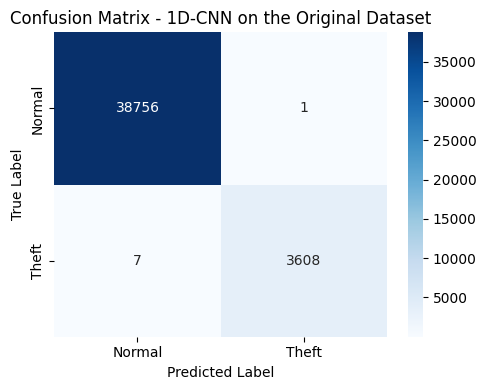

In [22]:
# ----------------------------
# Evaluate CNN on original dataset
# ----------------------------
# Evaluate the CNN detector on the original dataset
cm_cnn, y_pred_cnn = evaluate_detector_full_dataset_batched(
    detector,  # The CNN detector model
    X_scaled,  # Input features (original dataset)
    y_full,  # Ground truth labels
    device,  # Device to run the evaluation (CPU/GPU)
    "1D-CNN on the Original Dataset",  # Name for logging
    batch_size=256  # Batch size for evaluation
)

Next, we evaluate the model on the balanced set to compare with Sun et al.'s results.

Starting evaluation for 1D-CNN on the Balanced Dataset on 77514 samples in 303 batches...


Processing batches for 1D-CNN on the Balanced Dataset::  21%|██        | 63/303 [00:00<00:02, 87.09it/s]

  Processed batch 50/303


Processing batches for 1D-CNN on the Balanced Dataset::  36%|███▌      | 109/303 [00:01<00:02, 84.40it/s]

  Processed batch 100/303


...

  Processed batch 200/303


Processing batches for 1D-CNN on the Balanced Dataset::  86%|████████▋ | 262/303 [00:03<00:00, 84.46it/s]

  Processed batch 250/303


Processing batches for 1D-CNN on the Balanced Dataset:: 100%|██████████| 303/303 [00:03<00:00, 85.10it/s]


  Processed batch 300/303

--- Results for 1D-CNN on the Balanced Dataset ---
Accuracy: 0.9995
Precision (PPV): 1.0000
Recall (TPR): 0.9990
F1-Score: 0.9995
Matthews Correlation Coefficient (MCC): 0.9990
Confusion Matrix:
[[38756     1]
 [   37 38720]]


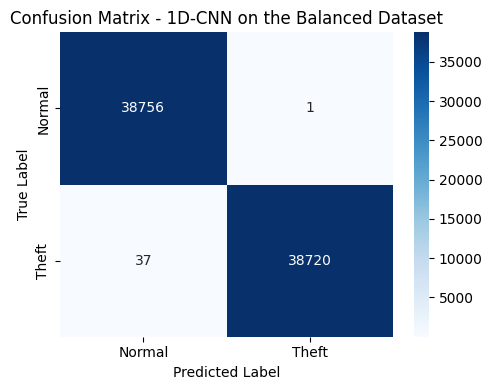

In [23]:
# ----------------------------
# Evaluate CNN on balanced dataset
# ----------------------------
# Evaluate the CNN detector on the balanced dataset
cm_cnn, y_pred_cnn = evaluate_detector_full_dataset_batched(
    detector,  # The CNN detector model
    X_full_balanced,  # Input features (balanced dataset)
    y_full_balanced,  # Ground truth labels
    device,  # Device to run the evaluation (CPU/GPU)
    "1D-CNN on the Balanced Dataset",  # Name for logging
    batch_size=256  # Batch size for evaluation
)

In [24]:
# ----------------------------
# Release CNN detector from GPU
# ----------------------------
detector.to("cpu")

# Clear the GPU memory cache
torch.cuda.empty_cache()

## 3.2 Bidirectional LSTM

We define the Bidirectional LSTM architecture as described in the report.

In [25]:
# ----------------------------
# BiLSTM Detector definition
# ----------------------------
class BiLSTM_Detector(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=2):
        """
        Initialize the BiLSTM Detector.

        Args:
            input_dim: Dimensionality of the input features.
            hidden_dim: Number of hidden units in the LSTM layers.
            num_layers: Number of LSTM layers.
        """
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,  # Input size for each time step
            hidden_size=hidden_dim,  # Number of hidden units
            num_layers=num_layers,  # Number of LSTM layers
            batch_first=True,  # Input and output tensors are provided as (batch, seq, feature)
            bidirectional=True  # Use bidirectional LSTM
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),  # Fully connected layer with input size = 2 * hidden_dim
            nn.SELU(),  # Activation function
            nn.Linear(32, 1),  # Output layer
            nn.Sigmoid()  # Sigmoid activation for binary classification
        )

    def forward(self, x):
        """
        Forward pass through the BiLSTM Detector.

        Args:
            x: Input tensor of shape (batch_size, sequence_length).

        Returns:
            Output tensor with predicted probabilities.
        """
        x = x.unsqueeze(-1)  # Add a feature dimension (B, L) → (B, L, 1)
        output, (h_n, c_n) = self.lstm(x)  # Pass through the LSTM layers
        # Concatenate the last hidden states from the forward and backward LSTMs
        features = torch.cat([h_n[-2], h_n[-1]], dim=1)  # Shape: (B, 2 * hidden_dim)
        return self.fc(features)  # Pass through the fully connected layers

We define the BiLSTM model, loss function, and optimizer.

In [26]:
# ----------------------------
# Initialize and configure BiLSTM training
# ----------------------------
# Initialize the BiLSTM detector and move it to the selected device
bilstm = BiLSTM_Detector(input_dim=X_balanced.shape[1]).to(device)

# Set the number of training epochs
epochs_bilstm = 1000

# Define the optimizer for the BiLSTM detector
bilstm_optimizer = optim.NAdam(bilstm.parameters(), lr=0.00005)

# Define the binary cross-entropy loss function for training
criterion = nn.BCELoss()

BiLSTM Training loop.

In [ ]:
# ----------------------------
# Train BiLSTM detector
# ----------------------------
for epoch in tqdm(range(epochs_bilstm), desc="BiLSTM Detector Training"):
    for x, y in train_loader:
        # Move the batch data to the selected device
        x, y = x.to(device), y.to(device)

        # Forward pass through the BiLSTM detector
        pred = bilstm(x)

        # Compute the binary cross-entropy loss
        loss = criterion(pred, y)

        # Zero the gradients
        bilstm_optimizer.zero_grad()

        # Backpropagate the loss
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(bilstm.parameters(), max_norm=1.0)

        # Update the model parameters
        bilstm_optimizer.step()

    # Log the loss every 20 epochs
    if epoch % 20 == 0:
        print(f"BiLSTM Epoch {epoch}: Loss={loss.item():.4f}")

BiLSTM Detector Training:   0%|          | 1/1000 [00:07<1:56:42,  7.01s/it]

BiLSTM Epoch 0: Loss=0.6940


BiLSTM Detector Training:   2%|▏         | 21/1000 [02:20<1:48:45,  6.67s/it]

BiLSTM Epoch 20: Loss=0.6929


BiLSTM Detector Training:   4%|▍         | 41/1000 [04:33<1:47:34,  6.73s/it]

...

BiLSTM Detector Training:  96%|█████████▌| 961/1000 [1:49:08<04:23,  6.76s/it]

BiLSTM Epoch 960: Loss=0.0008


BiLSTM Detector Training:  98%|█████████▊| 981/1000 [1:51:23<02:08,  6.76s/it]

BiLSTM Epoch 980: Loss=0.0009


BiLSTM Detector Training: 100%|██████████| 1000/1000 [1:53:31<00:00,  6.81s/it]


In [ ]:
# ----------------------------
# Save BiLSTM Detector
# ----------------------------
# Define the save path for the BiLSTM detector
bilstm_detector_save_path = "saved_models/bilstm_detector.pth"

# Create the directory for saving the model if it doesn't exist
os.makedirs(os.path.dirname(bilstm_detector_save_path), exist_ok=True)

# Save the BiLSTM detector state, including model weights and optimizer state
torch.save({
    'model_state_dict': bilstm.state_dict(),  # Save the model parameters
    'optimizer_state_dict': bilstm_optimizer.state_dict(),  # Save the optimizer state
    'epoch': epoch,  # Save the current epoch
}, bilstm_detector_save_path)

# Confirm the save operation
print(f"Detector saved to {bilstm_detector_save_path}")

Detector saved to saved_models/bilstm_detector.pth


In [27]:
# ----------------------------
# Load previously saved BiLSTM Detector for evaluation
# ----------------------------
# Define the path to the saved BiLSTM detector
bilstm_detector_load_path = "saved_models/bilstm_detector.pth"

# Load the saved checkpoint to the specified device
checkpoint = torch.load(bilstm_detector_load_path, map_location=device)

# Initialize the BiLSTM detector and move it to the selected device
bilstm = BiLSTM_Detector(input_dim).to(device)

# Load the model parameters from the checkpoint
bilstm.load_state_dict(checkpoint['model_state_dict'])

# Set the BiLSTM detector to evaluation mode
bilstm.eval()

# Confirm the model has been loaded successfully
print(f"BiLSTM Detector loaded from {bilstm_detector_load_path}")

BiLSTM Detector loaded from saved_models/bilstm_detector.pth


Again, we first evaluate the model on the original imbalanced set to see how the model performs on the problematic dataset.

Starting evaluation for BiLSTM on the Original Dataset on 42372 samples in 166 batches...


Processing batches for BiLSTM on the Original Dataset::  45%|████▍     | 74/166 [00:00<00:00, 117.14it/s]

  Processed batch 50/166


Processing batches for BiLSTM on the Original Dataset::  69%|██████▉   | 115/166 [00:01<00:00, 129.37it/s]

  Processed batch 100/166


Processing batches for BiLSTM on the Original Dataset:: 100%|██████████| 166/166 [00:01<00:00, 104.76it/s]


  Processed batch 150/166

--- Results for BiLSTM on the Original Dataset ---
Accuracy: 0.9981
Precision (PPV): 0.9992
Recall (TPR): 0.9790
F1-Score: 0.9890
Matthews Correlation Coefficient (MCC): 0.9880
Confusion Matrix:
[[38754     3]
 [   76  3539]]


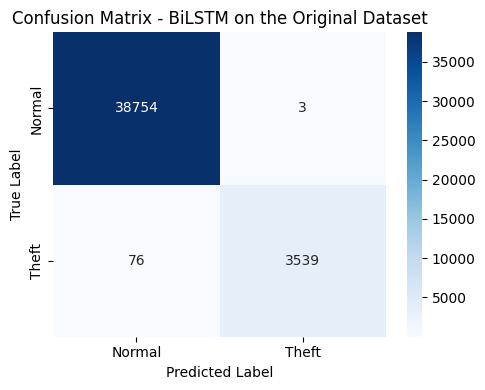

In [28]:
# ----------------------------
# Evaluate BiLSTM on original dataset
# ----------------------------
# Evaluate the BiLSTM detector on the original dataset
cm_bilstm, y_pred_bilstm = evaluate_detector_full_dataset_batched(
    bilstm,  # The BiLSTM detector model
    X_scaled,  # Input features (original dataset)
    y_full,  # Ground truth labels
    device,  # Device to run the evaluation (CPU/GPU)
    "BiLSTM on the Original Dataset",  # Name for logging
    batch_size=256  # Batch size for evaluation
)

Then, we evaluate the model on the full balanced set.

Starting evaluation for BiLSTM on the Balanced Dataset on 77514 samples in 303 batches...


Processing batches for BiLSTM on the Balanced Dataset::  25%|██▌       | 76/303 [00:00<00:01, 141.65it/s]

  Processed batch 50/303


Processing batches for BiLSTM on the Balanced Dataset::  40%|███▉      | 121/303 [00:00<00:01, 140.59it/s]

  Processed batch 100/303


...

  Processed batch 200/303


Processing batches for BiLSTM on the Balanced Dataset::  91%|█████████ | 275/303 [00:01<00:00, 146.28it/s]

  Processed batch 250/303


Processing batches for BiLSTM on the Balanced Dataset:: 100%|██████████| 303/303 [00:02<00:00, 143.57it/s]


  Processed batch 300/303

--- Results for BiLSTM on the Balanced Dataset ---
Accuracy: 0.9985
Precision (PPV): 0.9999
Recall (TPR): 0.9970
F1-Score: 0.9985
Matthews Correlation Coefficient (MCC): 0.9970
Confusion Matrix:
[[38754     3]
 [  115 38642]]


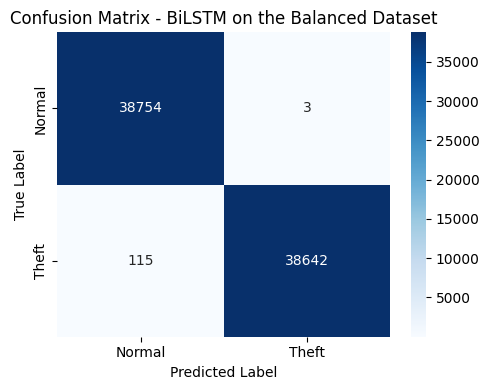

In [29]:
# ----------------------------
# Evaluate BiLSTM on balanced dataset
# ----------------------------
# Evaluate the BiLSTM detector on the balanced dataset
cm_bilstm, y_pred_bilstm = evaluate_detector_full_dataset_batched(
    bilstm,  # The BiLSTM detector model
    X_full_balanced,  # Input features (balanced dataset)
    y_full_balanced,  # Ground truth labels
    device,  # Device to run the evaluation (CPU/GPU)
    "BiLSTM on the Balanced Dataset",  # Name for logging
    batch_size=256  # Batch size for evaluation
)

In [30]:
# ----------------------------
# Release BiLSTM detector from GPU
# ----------------------------
bilstm.to("cpu")

# Clear the GPU memory cache
torch.cuda.empty_cache()

## 3.3 Transformer

We define the Transformer architecture as described in the report.

In [31]:
# ----------------------------
# Transformer Detector definition
# ----------------------------
class Transformer_Detector(nn.Module):
    def __init__(self, seq_len, d_model=64, nhead=4, num_layers=2):
        """
        Initialize the Transformer Detector.

        Args:
            seq_len: Length of the input sequence.
            d_model: Dimensionality of the model (embedding size).
            nhead: Number of attention heads.
            num_layers: Number of Transformer encoder layers.
        """
        super().__init__()
        self.embedding = nn.Linear(1, d_model)  # Linear layer to project input to d_model dimensions
        self.pos_encoding = nn.Parameter(torch.zeros(1, seq_len, d_model))  # Positional encoding
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=128, batch_first=True, dropout=0.2
        )  # Transformer encoder layer
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)  # Transformer encoder
        self.dropout = nn.Dropout(0.2)  # Dropout layer
        self.pool = nn.AdaptiveMaxPool1d(1)  # Adaptive max pooling
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),  # Fully connected layer
            nn.ReLU(),  # Activation function
            nn.Linear(32, 1),  # Output layer
            nn.Sigmoid()  # Sigmoid activation for binary classification
        )

    def forward(self, x):
        """
        Forward pass through the Transformer Detector.

        Args:
            x: Input tensor of shape (batch_size, sequence_length).

        Returns:
            Output tensor with predicted probabilities.
        """
        x = x.unsqueeze(-1)  # Add a feature dimension (B, L) → (B, L, 1)
        x = self.embedding(x) + self.pos_encoding  # Add positional encoding to the input embeddings
        x = self.transformer(x)  # Pass through the Transformer encoder
        x = self.dropout(x)  # Apply dropout
        x = x.transpose(1, 2)  # Transpose for pooling (B, d_model, L)
        x = self.pool(x).squeeze(-1)  # Apply adaptive max pooling and remove the last dimension
        return self.fc(x)  # Pass through the fully connected layers

We define the transformer model, loss function, and optimizer.

In [32]:
# ----------------------------
# Initialize and configure Transformer training
# ----------------------------
# Initialize the Transformer detector and move it to the selected device
transformer = Transformer_Detector(seq_len=X_balanced.shape[1]).to(device)

# Define the optimizer for the Transformer detector
transformer_optimizer = optim.AdamW(transformer.parameters(), lr=0.0002)

# Define the binary cross-entropy loss function for training
criterion = nn.BCELoss()

# Set the number of training epochs
epochs_trans = 1000

Transformer Training loop.

In [ ]:
# ----------------------------
# Train Transformer detector
# ----------------------------
for epoch in tqdm(range(epochs_trans), desc="Transformer Detector Training"):
    for x, y in train_loader:
        # Move the batch data to the selected device
        x, y = x.to(device), y.to(device)

        # Forward pass through the Transformer detector
        pred = transformer(x)

        # Compute the binary cross-entropy loss
        loss = criterion(pred, y)

        # Zero the gradients
        transformer_optimizer.zero_grad()

        # Backpropagate the loss
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)

        # Update the model parameters
        transformer_optimizer.step()

    # Log the loss every 20 epochs
    if epoch % 20 == 0:
        print(f"Transformer Epoch {epoch}: Loss={loss.item():.4f}")

Transformer Detector Training:   0%|          | 1/1000 [01:58<33:00:20, 118.94s/it]

Transformer Epoch 0: Loss=0.0034


Transformer Detector Training:   2%|▏         | 21/1000 [41:17<31:59:56, 117.67s/it]

Transformer Epoch 20: Loss=0.0018


Transformer Detector Training:   4%|▍         | 41/1000 [1:20:34<31:40:18, 118.89s/it]

...

Transformer Detector Training:  96%|█████████▌| 961/1000 [31:40:43<1:17:02, 118.52s/it]

Transformer Epoch 960: Loss=0.0008


Transformer Detector Training:  98%|█████████▊| 981/1000 [32:20:12<37:23, 118.09s/it]

Transformer Epoch 980: Loss=0.0009


Transformer Detector Training: 100%|██████████| 1000/1000 [32:57:39<00:00, 118.66s/it]


In [ ]:
# ----------------------------
# Save Transformer Detector
# ----------------------------
# Define the save path for the Transformer detector
transformer_detector_save_path = "saved_models/transformer_detector.pth"

# Create the directory for saving the model if it doesn't exist
os.makedirs(os.path.dirname(transformer_detector_save_path), exist_ok=True)

# Save the Transformer detector state, including model weights and optimizer state
torch.save({
    'model_state_dict': transformer.state_dict(),  # Save the model parameters
    'optimizer_state_dict': transformer_optimizer.state_dict(),  # Save the optimizer state
    'epoch': epoch,  # Save the current epoch
}, transformer_detector_save_path)

# Confirm the save operation
print(f"Detector saved to {transformer_detector_save_path}")

Detector saved to saved_models/transformer_detector.pth


In [33]:
# ----------------------------
# Load previously saved Transformer Detector for evaluation
# ----------------------------
# Define the path to the saved Transformer detector
transformer_detector_load_path = "saved_models/transformer_detector.pth"

# Load the saved checkpoint to the specified device
checkpoint = torch.load(transformer_detector_load_path, map_location=device)

# Initialize the Transformer detector and move it to the selected device
transformer = Transformer_Detector(seq_len=input_dim).to(device)

# Load the model parameters from the checkpoint
transformer.load_state_dict(checkpoint['model_state_dict'])

# Set the Transformer detector to evaluation mode
transformer.eval()

# Confirm the model has been loaded successfully
print(f"Transformer Detector loaded from {transformer_detector_load_path}")

Transformer Detector loaded from saved_models/transformer_detector.pth


Once again, we first evaluate the model on the original imbalanced set to see how the model performs on the problematic dataset.

Starting evaluation for Transformer on the Original Dataset on 42372 samples in 166 batches...


Processing batches for Transformer on the Original Dataset::  31%|███       | 51/166 [00:07<00:15,  7.36it/s]

  Processed batch 50/166


Processing batches for Transformer on the Original Dataset::  61%|██████    | 101/166 [00:14<00:09,  7.16it/s]

  Processed batch 100/166


Processing batches for Transformer on the Original Dataset::  91%|█████████ | 151/166 [00:21<00:02,  7.20it/s]

  Processed batch 150/166


Processing batches for Transformer on the Original Dataset:: 100%|██████████| 166/166 [00:23<00:00,  7.14it/s]



--- Results for Transformer on the Original Dataset ---
Accuracy: 0.9984
Precision (PPV): 0.9989
Recall (TPR): 0.9823
F1-Score: 0.9905
Matthews Correlation Coefficient (MCC): 0.9897
Confusion Matrix:
[[38753     4]
 [   64  3551]]


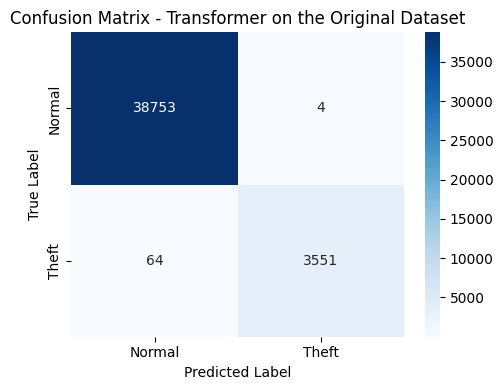

In [34]:
# ----------------------------
# Evaluate Transformer on original dataset
# ----------------------------
# Evaluate the Transformer detector on the original dataset
cm_trans, y_pred_trans = evaluate_detector_full_dataset_batched(
    transformer,  # The Transformer detector model
    X_scaled,  # Input features (original dataset)
    y_full,  # Ground truth labels
    device,  # Device to run the evaluation (CPU/GPU)
    "Transformer on the Original Dataset",  # Name for logging
    batch_size=256  # Batch size for evaluation
)

Then, we evaluate the model on the full balanced set.

Starting evaluation for Transformer on the Balanced Dataset on 77514 samples in 303 batches...


Processing batches for Transformer on the Balanced Dataset::  17%|█▋        | 51/303 [00:07<00:34,  7.23it/s]

  Processed batch 50/303


Processing batches for Transformer on the Balanced Dataset::  33%|███▎      | 101/303 [00:14<00:29,  6.86it/s]

  Processed batch 100/303


...

  Processed batch 250/303


Processing batches for Transformer on the Balanced Dataset::  99%|█████████▉| 301/303 [00:44<00:00,  6.37it/s]

  Processed batch 300/303


Processing batches for Transformer on the Balanced Dataset:: 100%|██████████| 303/303 [00:45<00:00,  6.73it/s]



--- Results for Transformer on the Balanced Dataset ---
Accuracy: 0.9987
Precision (PPV): 0.9999
Recall (TPR): 0.9974
F1-Score: 0.9987
Matthews Correlation Coefficient (MCC): 0.9973
Confusion Matrix:
[[38753     4]
 [   99 38658]]


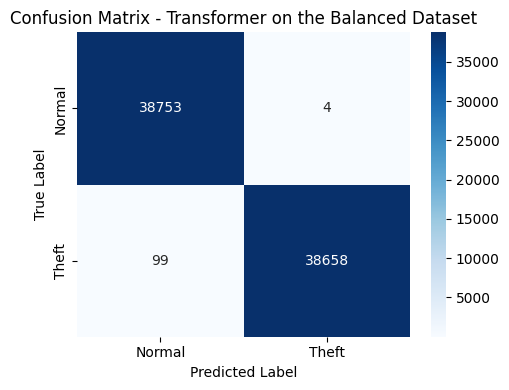

In [35]:
# ----------------------------
# Evaluate Transformer on balanced dataset
# ----------------------------
# Evaluate the Transformer detector on the balanced dataset
cm_trans, y_pred_trans = evaluate_detector_full_dataset_batched(
    transformer,  # The Transformer detector model
    X_full_balanced,  # Input features (balanced dataset)
    y_full_balanced,  # Ground truth labels
    device,  # Device to run the evaluation (CPU/GPU)
    "Transformer on the Balanced Dataset",  # Name for logging
    batch_size=256  # Batch size for evaluation
)

In [36]:
# ----------------------------
# Release Transformer detector from GPU
# ----------------------------
transformer.to("cpu")

# Clear the GPU memory cache
torch.cuda.empty_cache()

Finally, we export the models to ONYX format to obtain the models architectures we presented on the report.

In [37]:
# ----------------------------
# Export models to ONNX
# ----------------------------
# Define the directory for ONNX exports
onnx_dir = "onnx_exports"
os.makedirs(onnx_dir, exist_ok=True)  # Create the directory if it doesn't exist

# 1. VAE-GAN Encoder
encoder_onnx = os.path.join(onnx_dir, "vae_gan_encoder.onnx")  # Path for the encoder ONNX file
dummy_input = torch.randn(1, input_dim).to("cpu")  # Dummy input for export
vae_gan.encoder.to("cpu")  # Move the encoder to CPU
torch.onnx.export(
    vae_gan.encoder, dummy_input, encoder_onnx,
    input_names=["input"], output_names=["mu", "logvar"],  # Define input and output names
    dynamic_axes={"input": {0: "batch"}},  # Allow dynamic batch size
    opset_version=17  # ONNX opset version
)
print(f"VAE-GAN Encoder exported to {encoder_onnx}")

# 2. VAE-GAN Generator
generator_onnx = os.path.join(onnx_dir, "vae_gan_generator.onnx")  # Path for the generator ONNX file
z = torch.randn(1, latent_dim).to("cpu")  # Dummy latent vector for export
vae_gan.generator.to("cpu")  # Move the generator to CPU
torch.onnx.export(
    vae_gan.generator, z, generator_onnx,
    input_names=["z"], output_names=["generated"],  # Define input and output names
    dynamic_axes={"z": {0: "batch"}},  # Allow dynamic batch size
    opset_version=17  # ONNX opset version
)
print(f"VAE-GAN Generator exported to {generator_onnx}")

# 3. VAE-GAN Discriminator
discriminator_onnx = os.path.join(onnx_dir, "vae_gan_discriminator.onnx")  # Path for the discriminator ONNX file
vae_gan.discriminator.to("cpu")  # Move the discriminator to CPU
torch.onnx.export(
    vae_gan.discriminator, dummy_input, discriminator_onnx,
    input_names=["input"], output_names=["score"],  # Define input and output names
    dynamic_axes={"input": {0: "batch"}},  # Allow dynamic batch size
    opset_version=17  # ONNX opset version
)
print(f"VAE-GAN Discriminator exported to {discriminator_onnx}")

# 4. CNN Detector
cnn_onnx = os.path.join(onnx_dir, "cnn_detector.onnx")  # Path for the CNN ONNX file
cnn_dummy = torch.randn(1, input_dim).to("cpu")  # Dummy input for export
detector.to("cpu")  # Move the CNN detector to CPU
torch.onnx.export(
    detector, cnn_dummy, cnn_onnx,
    input_names=["input"], output_names=["score"],  # Define input and output names
    dynamic_axes={"input": {0: "batch"}},  # Allow dynamic batch size
    opset_version=17  # ONNX opset version
)
print(f"CNN Detector exported to {cnn_onnx}")

# 5. BiLSTM Detector
bilstm_onnx = os.path.join(onnx_dir, "bilstm_detector.onnx")  # Path for the BiLSTM ONNX file
bilstm_dummy = torch.randn(1, input_dim).to("cpu")  # Dummy input for export
bilstm.to("cpu")  # Move the BiLSTM detector to CPU
torch.onnx.export(
    bilstm, bilstm_dummy, bilstm_onnx,
    input_names=["input"], output_names=["score"],  # Define input and output names
    dynamic_axes={"input": {0: "batch"}},  # Allow dynamic batch size
    opset_version=17  # ONNX opset version
)
print(f"BiLSTM Detector exported to {bilstm_onnx}")

# 6. Transformer Detector
transformer_onnx = os.path.join(onnx_dir, "transformer_detector.onnx")  # Path for the Transformer ONNX file
transformer_dummy = torch.randn(1, input_dim).to("cpu")  # Dummy input for export
transformer.to("cpu")  # Move the Transformer detector to CPU
torch.onnx.export(
    transformer, transformer_dummy, transformer_onnx,
    input_names=["input"], output_names=["score"],  # Define input and output names
    dynamic_axes={"input": {0: "batch"}},  # Allow dynamic batch size
    opset_version=17  # ONNX opset version
)
print(f"Transformer Detector exported to {transformer_onnx}")

VAE-GAN Encoder exported to onnx_exports/vae_gan_encoder.onnx
VAE-GAN Generator exported to onnx_exports/vae_gan_generator.onnx
VAE-GAN Discriminator exported to onnx_exports/vae_gan_discriminator.onnx
CNN Detector exported to onnx_exports/cnn_detector.onnx
BiLSTM Detector exported to onnx_exports/bilstm_detector.onnx
Transformer Detector exported to onnx_exports/transformer_detector.onnx
